# Generate All Paper Figures

In [1]:
# =============================================================================
# Master figure-generation notebook.
# Loads all pre-computed pkl files and produces every paper figure + Table 2.
# Run this after all upstream notebooks (03, 04a, 04b, 05a) have completed.
# =============================================================================

In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from copy import deepcopy

from pdspl_utils.plotting import plot_dspl_corner
from pdspl_utils.pairing import (
    plot_dataset_corner,
    plot_reldiff_corner,
    plot_beta_E_vs_D_MC,
    plot_pairing_scatter,
    generate_latex_summary_table,
)

%load_ext autoreload
%autoreload 2

FIGURE_DIRECTORY = "../figures/all_paper_figures"
os.makedirs(FIGURE_DIRECTORY, exist_ok=True)

In [3]:
# ── Cell 2: Load all pre-computed data ───────────────────────────────────────
with open("../data/samples/pdspl_samples_with_pairs.pkl", "rb") as f:
    pdspl_samples = pickle.load(f)

with open("../data/samples/mc_results_pairing.pkl", "rb") as f:
    mc_results = pickle.load(f)

with open("../data/samples/forecast_scenarios_w0waCDM_fixed_scatter.pkl", "rb") as f:
    fixed_scenarios = pickle.load(f)

with open("../data/samples/forecast_scenarios_w0waCDM_free_scatter_lsst_y10.pkl", "rb") as f:
    free_scenarios = pickle.load(f)

# Experiment 05a data
with open("../data/samples/mc_results_photo_vs_specz.pkl", "rb") as f:
    mc_results_expt = pickle.load(f)

with open("../data/samples/forecast_scenarios_photo_vs_specz.pkl", "rb") as f:
    photo_specz_scenarios = pickle.load(f)

# pdspl_samples_expt for Figure 9 (must have 'pairs_analysis' key)
with open("../data/samples/pdspl_samples_expt_photo_vs_specz.pkl", "rb") as f:
    pdspl_samples_expt = pickle.load(f)

fixed_scenarios_with_stats = deepcopy(fixed_scenarios)

# Update legend names to include stats
for key, sc in fixed_scenarios_with_stats.items():
    if key == 'DSPL' or key == 'DSPL_om_prior':
        continue
    else:
        # Match the pdspl_samples key (e.g., 'lsst_y10')
        sample_key = key.replace('_om_prior', '')
        pair_count = int(pdspl_samples[sample_key]['pairs_analysis']['mean_num_pairs'])
        lens_count = int(pdspl_samples[sample_key]['pairs_analysis']['num_lenses'])

    sc['name'] = f"{sc['name']} [{round(lens_count/1000, 1)}K lenses / {round(pair_count/1000, 1)}K pairs]"

In [4]:
# ── Cell 3: Accessible colour palette (Okabe-Ito) ────────────────────────────
C_SKYBLUE   = "#56B4E9"
C_ORANGE    = "#E69F00"
C_GREEN     = "#009E73"
C_VERMILION = "#D55E00"
C_PURPLE    = "#CC79A7"
C_BLUE      = "#0072B2"
C_BLACK     = "#000000"

accessible_colors = {
    "lsst_y1":                   C_ORANGE,
    "lsst_y10":                  C_GREEN,
    "lsst_y10_baseline":         C_GREEN,
    "lsst_4most_spec-z":         C_PURPLE,
    "lsst_4most_spec-z_sigma_v": C_BLUE,
    "DSPL":                      C_SKYBLUE,
    "lsst_y10_om_prior":         C_BLACK,
    "DSPL_om_prior":             C_BLUE,
    "lsst_y10_photo_z":          C_GREEN,
    "lsst_y10_spec_z":           C_BLUE,
    "lsst_y10_zD_spec":          C_SKYBLUE,
    "lsst_y10_all_spec":         C_PURPLE,
}
accessible_markers = {
    "lsst_y1":                   "^",
    "lsst_y10":                  "o",
    "lsst_4most_spec-z":         "s",
    "lsst_4most_spec-z_sigma_v": "D",
    "lsst_y10_photo_z":          "o",
    "lsst_y10_spec_z":           "s",
}

truth = {
    "h0": 70.0, "om": 0.3, "w0": -1.0, "wa": 0.0,
    "lambda_int":  1.0,  "lambda_sigma": 0.05,
    "gamma_pl":    2.078,  "gamma_sigma":  0.16,
}
fixed_params = {"h0": 70.0}
latex_labels = {
    "om":           r"$\Omega_{\rm m}$",
    "w0":           r"$w_0$",
    "wa":           r"$w_a$",
    "lambda_int":   r"$\overline{\lambda}_{\rm MST}$",
    "lambda_sigma": r"$\sigma({\lambda}_{\rm MST})$",
    "gamma_pl":     r"$\overline{\gamma}_{\rm pl}$",
    "gamma_sigma":  r"$\sigma({\gamma}_{\rm pl})$",
    "beta_c0":      r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}^{(0)}$",
    "beta_c1":      r"$\sigma_{\beta_{\rm E},\rm \mathcal{D}}^{(1)}$",
}
custom_ranges = [
    (0, 1), (-2, 0), (-3, 3),
    (0.8, 1.2), (0.0, 3*truth["lambda_sigma"]),
    (truth["gamma_pl"] - 0.5, truth["gamma_pl"] + 0.5), 
    (0.0, 2*truth["gamma_sigma"]),
]

Generating Figure 3: unpaired GGL population corner plot...
  → saved


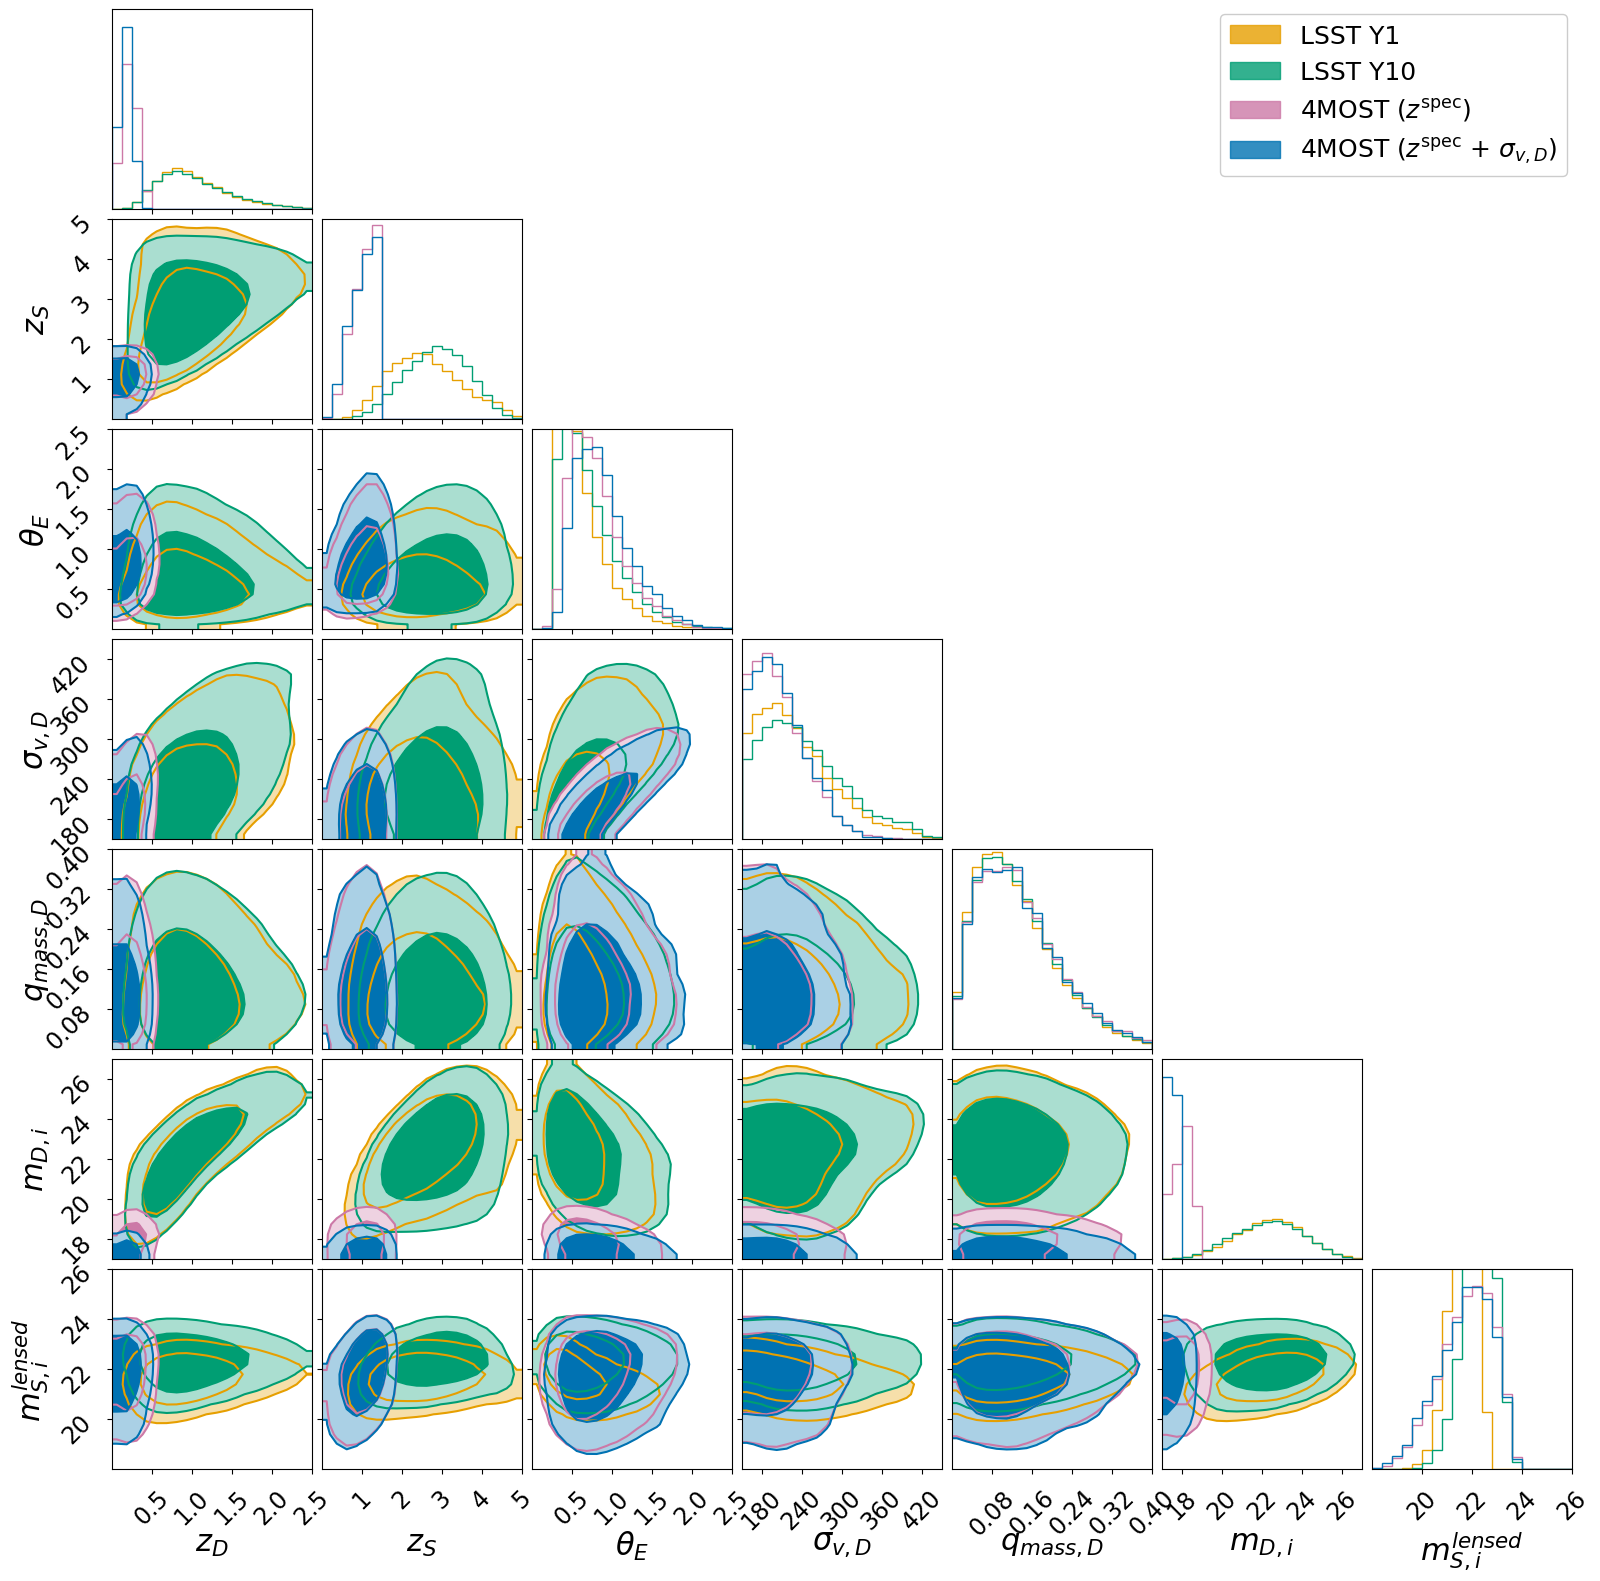

In [5]:
# ── Cell 4: Figure 3 — Unpaired population corner plot ───────────────────────
print("Generating Figure 3: unpaired GGL population corner plot...")
fig3 = plot_dataset_corner(
    pdspl_samples,
    samples_to_plot=["lsst_y1", "lsst_y10", "lsst_4most_spec-z", "lsst_4most_spec-z_sigma_v"],
    key_list=["z_D", "z_S", "theta_E", "sigma_v_D", "e_mass_D", "mag_D_i", "mag_S_i_lensed"],
    key_latex_labels={
        "z_D":            r"$z_D$",
        "z_S":            r"$z_S$",
        "theta_E":        r"$\theta_E$",
        "sigma_v_D":      r"$\sigma_{v, D}$",
        "e_mass_D":       r"$q_{mass, D}$",
        "mag_D_i":        r"$m_{D, i}$",
        "mag_S_i_lensed": r"$m_{S, i}^{lensed}$",
    },
    plot_ranges=[(0.0, 2.5), (0.0, 5.0), (0.0, 2.5), (150, 450), (0, 0.4), (17, 27), (18, 26)],
    save_path=f"{FIGURE_DIRECTORY}/slsim_corner_GGL_all_samples_v2.pdf",
    custom_colors_dict=accessible_colors,
)
# plt.close(fig3)
print("  → saved")

Generating Figure 4: beta_E vs D (main samples)...


  → saved


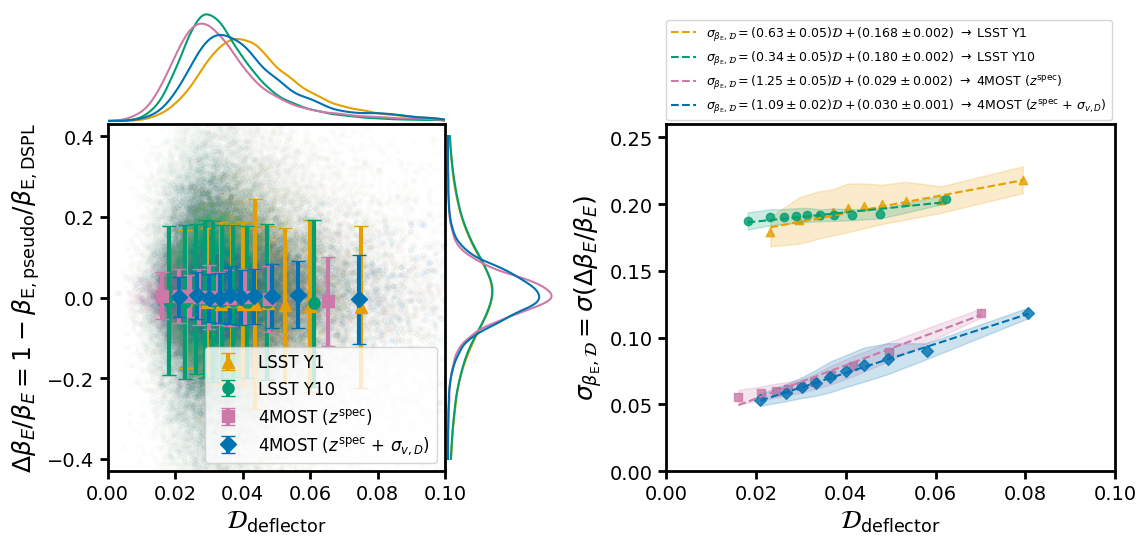

In [6]:
# ── Cell 5: Figure 4 — β_E vs D (main samples, linear fit) ───────────────
print("Generating Figure 4: beta_E vs D (main samples)...")
fig4 = plot_beta_E_vs_D_MC(
    pdspl_samples, mc_results,
    fit_type="linear",
    custom_colors_dict=accessible_colors,
    custom_markers_dict=accessible_markers,
    save_path=f"{FIGURE_DIRECTORY}/beta_E_vs_D_MC.png",
)
# plt.close(fig4)
print("  → saved")

Generating Figure 4b: pairing scatter (lens 1 vs lens 2)...


/tmp/ipykernel_99009/989386125.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig4b.tight_layout()


  → saved


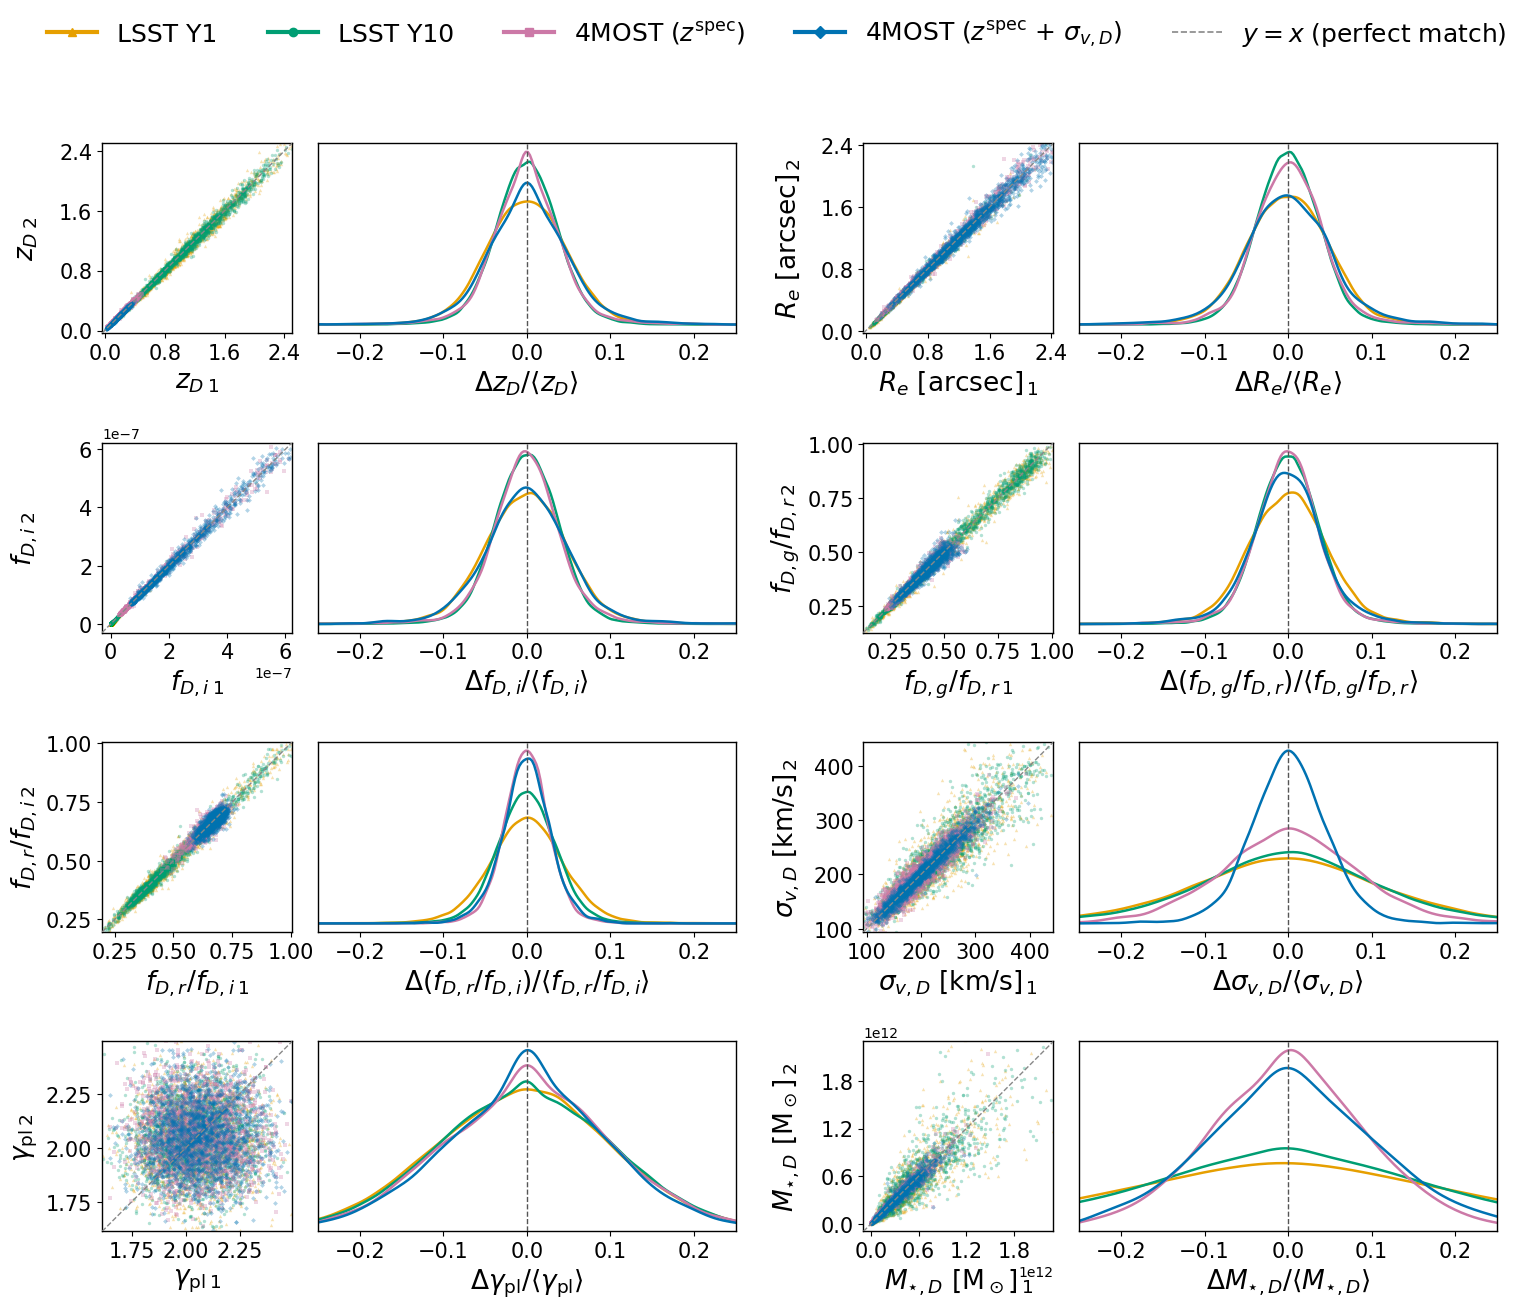

In [23]:
# ── Cell 5b: Figure 4b — Pairing scatter (lens 1 vs lens 2) ──────────────────
# Primary pairing-quality figure: lens 1 vs lens 2 scatter with y=x diagonal,
# plus KDE of relative differences, for all six pairing parameters.
print("Generating Figure 4b: pairing scatter (lens 1 vs lens 2)...")

_pairing_scatter_keys = [
    "z_D", "R_e_arcsec",
    "flux_D_i", "flux_ratio_D_gr",
    "flux_ratio_D_ri", "sigma_v_D",
    "gamma_pl", "stellar_mass_D"
]
_pairing_scatter_labels = {
    "z_D":             r"$z_D$",
    "R_e_arcsec":      r"$R_e$ [arcsec]",
    "flux_D_i":        r"$f_{D,i}$",
    "flux_ratio_D_gr": r"$f_{D,g}/f_{D,r}$",
    "flux_ratio_D_ri": r"$f_{D,r}/f_{D,i}$",
    "sigma_v_D":       r"$\sigma_{v,D}$ [km/s]",
    "gamma_pl":        r"$\gamma_{\rm pl}$",
    "stellar_mass_D":  r"$M_{\star,D}$ [M$_\odot$]",
}
_pairing_hist_labels = {
    "z_D":             r"$\Delta z_D / \langle z_D \rangle$",
    "R_e_arcsec":      r"$\Delta R_e / \langle R_e \rangle$",
    "flux_D_i":        r"$\Delta f_{D,i} / \langle f_{D,i} \rangle$",
    "flux_ratio_D_gr": r"$\Delta (f_{D,g}/f_{D,r}) / \langle f_{D,g}/f_{D,r} \rangle$",
    "flux_ratio_D_ri": r"$\Delta (f_{D,r}/f_{D,i}) / \langle f_{D,r}/f_{D,i} \rangle$",
    "sigma_v_D":       r"$\Delta \sigma_{v,D} / \langle \sigma_{v,D} \rangle$",
    "gamma_pl":        r"$\Delta \gamma_{\rm pl} / \langle \gamma_{\rm pl} \rangle$",
    "stellar_mass_D":  r"$\Delta M_{\star,D} / \langle M_{\star,D} \rangle$",
}

fig4b = plot_pairing_scatter(
    pdspl_samples=pdspl_samples,
    samples_to_plot=["lsst_y1", "lsst_y10", "lsst_4most_spec-z", "lsst_4most_spec-z_sigma_v"],
    pairing_param_keys=_pairing_scatter_keys,
    pairing_param_labels=_pairing_scatter_labels,
    pairing_hist_labels=_pairing_hist_labels,
    custom_colors_dict=accessible_colors,
    custom_markers_dict=accessible_markers,
    n_scatter_points=2000,
    save_path=f"{FIGURE_DIRECTORY}/pairing_scatter_lens1_vs_lens2.pdf",
    reldiff_range=(-0.25, 0.25),
)
fig4b.tight_layout()
# plt.close(fig4b)
print("  → saved")

In [20]:
pdspl_samples['lsst_y1']['table']

lens_id,z_D,z_S,theta_E,num_images,radial_dist_S,size_S,mag_S_g,mag_S_g_lensed,mag_D_g,mag_S_r,mag_S_r_lensed,mag_D_r,mag_S_i,mag_S_i_lensed,mag_D_i,mag_S_z,mag_S_z_lensed,mag_D_z,mag_S_y,mag_S_y_lensed,mag_D_y,es_magnification,R_e_arcsec,surf_bri_mag/arcsec2,sigma_v_D,stellar_mass_D,e1_mass_D,e2_mass_D,e_mass_D,gamma_pl,R_e_kpc,Sigma_half_Msun/pc2,contrast_ratio_g,contrast_ratio_r,contrast_ratio_i,contrast_ratio_z,contrast_ratio_y,snr_g,snr_r,snr_i,color_D_gr,color_D_ri,flux_D_i,flux_ratio_D_gr,flux_ratio_D_ri,log_R_e_kpc,log_Sigma_half_Msun/pc2,log_sigma_v_D
bytes13,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
lens_28_45485,0.6594111484376102,1.012553845542648,0.42525820795436253,4,0.07137954449607885,0.3021455035196603,22.341716528433132,20.729440743635266,23.057489433178052,21.765816895803887,20.15354111100602,21.629866714842354,21.075200845223883,19.462925060426016,20.475750429968524,20.399186960038627,18.78691117524076,20.05784620464873,20.105744522510292,18.493468737712426,19.764017369442815,4.4147926812907725,0.4550608556284175,23.859567194039602,220.11764309123228,342184076444.92365,0.1657499038114637,-0.02776650351603567,0.16805954102940865,2.069470799918824,3.1726862883470526,7586.467143886521,[-3.32061762 -3.27111551 -2.82639675 -2.21145077],[-2.46889453 -2.41939243 -1.97467367 -1.35972769],[-2.0053943 -1.95589219 -1.51117343 -0.89622745],[-2.26350396 -2.21400185 -1.76928309 -1.15433711],[-2.26311756 -2.21361545 -1.7688967 -1.15395071],1093.6930493323414,1871.277312302893,2189.2332949611114,1.427622718335698,1.1541162848738296,6.4520812538940966e-09,0.2685040944332162,0.34542477712721387,0.5014271316732609,3.880039581283439,2.342654853957617
lens_69_13679,0.40731693130328706,0.7432303521202558,0.45816964023750006,2,0.11538360137361377,0.1802896100860232,22.97577399167177,20.716430079692365,21.333434670126792,22.38105283854642,20.121708926567017,19.866690353521918,21.662720585025287,19.403376673045884,19.261442509811417,21.464125861856584,19.20478194987718,18.93231190421338,21.348570412754146,19.089226500774743,18.74641940235361,8.011937721881852,0.8746068189951131,23.50559581158291,196.06258829466086,240496278285.38797,-0.055837193359796096,-0.01643269625392184,0.05820503129861639,1.9009113551353285,4.751112357751164,3852.7672490129385,[-2.2882657 -1.62765103 nan nan],[-1.41624253 -0.75562787 nan nan],[-1.52932694 -0.86871228 nan nan],[-1.39879106 -0.73817639 nan nan],[-1.32845401 -0.66783934 nan nan],1037.73919545393,1729.6404844005456,2124.2752837199596,1.4667443166048741,0.6052478437105009,1.9743447810728315e-08,0.25900149646057113,0.5726652923302841,0.6767953010515648,3.585772773476395,2.2923947316216755
lens_97_27872,0.35004593572075865,0.7135019389133476,0.5264842351192844,4,0.06730664960815962,0.25615966625114656,22.376594935365613,20.405260026433705,20.969353133918226,21.93412043751542,19.962785528583513,19.458873304156853,21.32842937186111,19.3570944629292,18.873853313209338,21.086917996696098,19.11558308776419,18.56944062468046,20.935453433385565,18.964118524453657,18.38027239643464,6.14517087531018,0.7428369265190881,22.82919331275388,196.8038106284398,243502922333.67987,0.20211174968089476,-0.06710739457712811,0.21296140910034153,1.9898266103358453,3.6697577013386353,4911.87295716433,[-2.21195929 -2.00402289 -1.10251151 -1.10748927],[-1.14395396 -0.93601756 -0.03450617 -0.03948394],[-1.16462504 -0.95668863 -0.05517725 -0.06015501],[-1.10172372 -0.89378732 0.00772406 0.0027463 ],[-1.06402006 -0.85608365 0.04542773 0.04044997],1214.8643850541869,1762.1077352864734,1986.1031046327223,1.5104798297613726,0.5850199909475151,2.8213611037515634e-08,0.2487757636832598,0.583434361781204,

In [8]:
# ── Cell 6: Table 2 — LaTeX pairing statistics ────────────────────────────────
print("\nGenerating Table 2 (LaTeX):")
generate_latex_summary_table(
    pdspl_samples,
    ["lsst_y1", "lsst_y10", "lsst_4most_spec-z", "lsst_4most_spec-z_sigma_v"],
)


Generating Table 2 (LaTeX):
\begin{tabular}{l | c c c | c c}
\hline
\multirow{2}{*}{\textbf{Sample}} & \multicolumn{3}{c|}{\textbf{Pairing at 20K deg$^2$}} & \multicolumn{2}{c}{\textbf{Linear Fit}} \\
 & \textbf{\# Lenses} & \textbf{Mean \# Pairs} & \textbf{$\overline{\Delta\beta_{\rm E}/\beta_{\rm E}}$} & \textbf{$\sigma_{\beta_{\rm E},\rm \mathcal{D}}^{(0)}$} & \textbf{$\sigma_{\beta_{\rm E},\rm \mathcal{D}}^{(1)}$} \\
\hline
LSST Y1 & 36831 & 27141 & 0.198 & 0.168 $\pm$ 0.002 & 0.63 $\pm$ 0.05 \\
LSST Y10 & 116471 & 85819 & 0.193 & 0.180 $\pm$ 0.002 & 0.34 $\pm$ 0.05 \\
4MOST ($z^{\rm spec}$) & 10000 & 7324 & 0.078 & 0.029 $\pm$ 0.002 & 1.25 $\pm$ 0.05 \\
4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$) & 5000 & 3711 & 0.084 & 0.030 $\pm$ 0.001 & 1.09 $\pm$ 0.02 \\
\hline
\end{tabular}

% Note: a single lens may appear in more than one pair because the kD-Tree
% assigns each lens its nearest neighbour independently (not a one-to-one matching).



Generating Figure 5: relative-difference corner...
  → saved


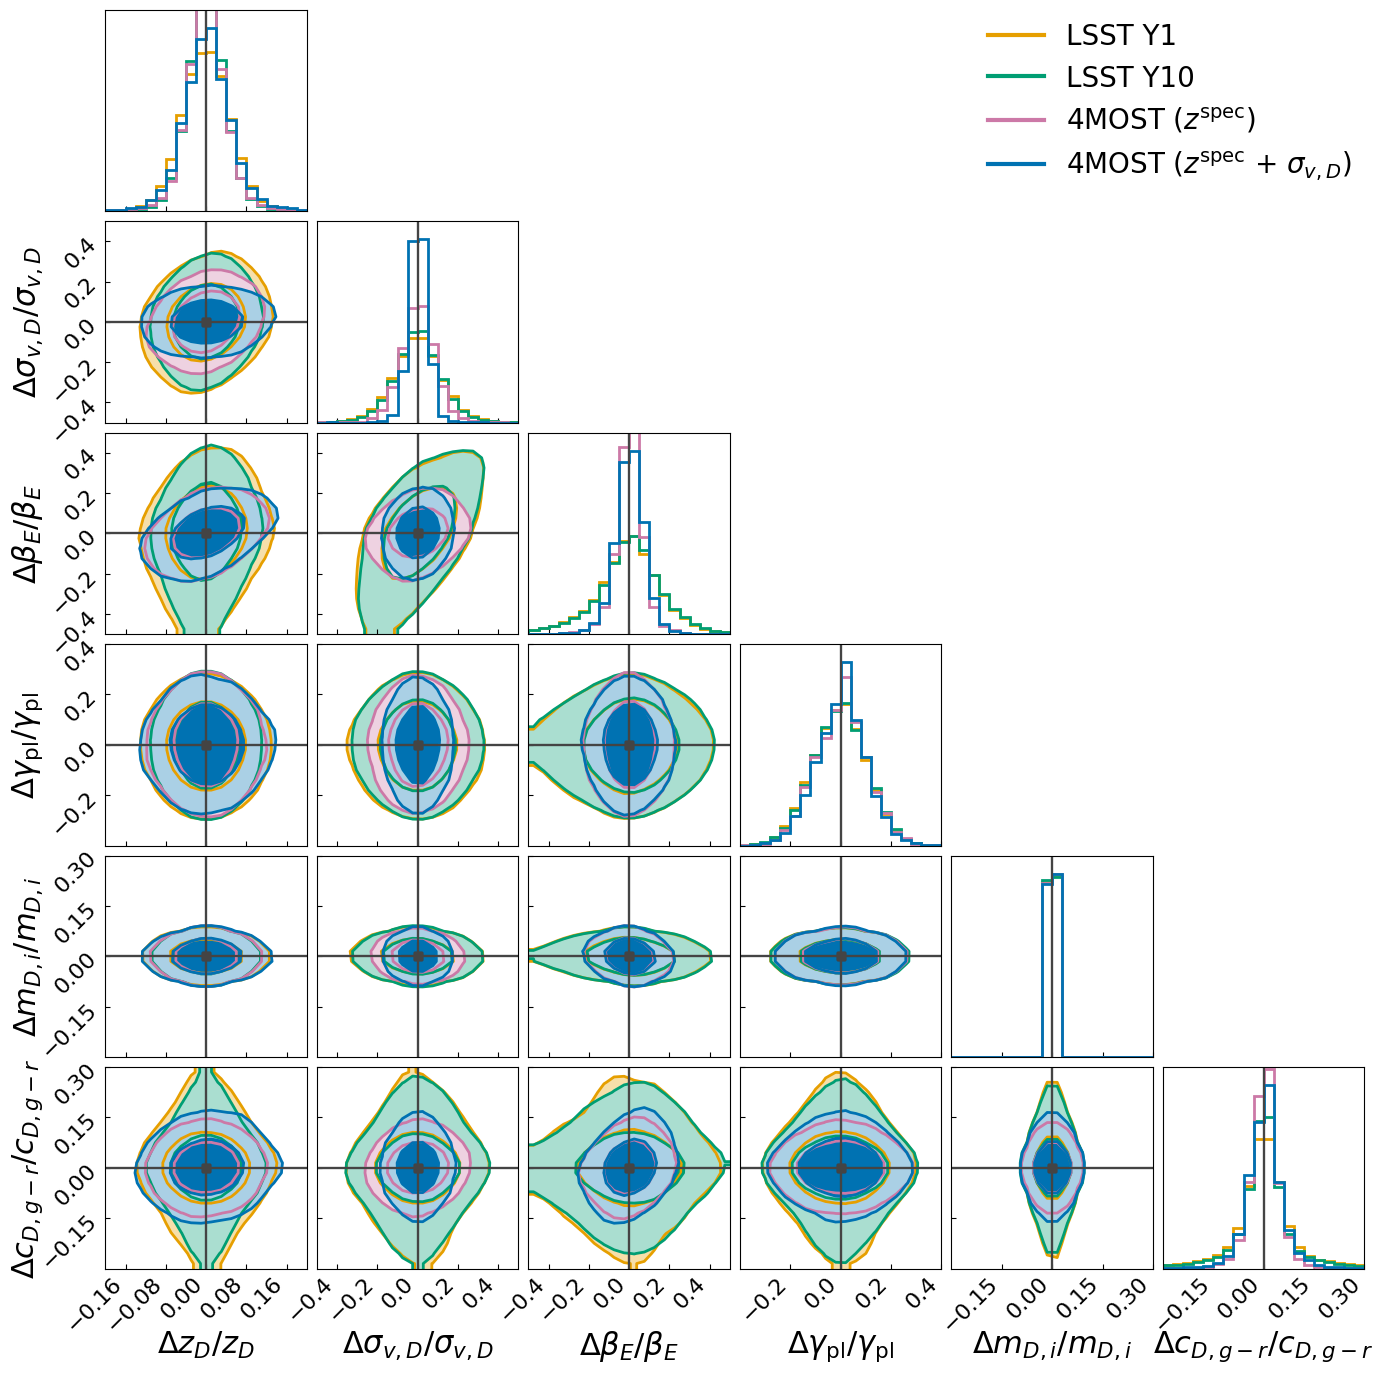

In [9]:
# ── Cell 7: Figure 5 — Relative-difference corner ────────────────────────────
print("\nGenerating Figure 5: relative-difference corner...")
fig5 = plot_reldiff_corner(
    pdspl_samples,
    samples_to_plot=["lsst_y1", "lsst_y10", "lsst_4most_spec-z", "lsst_4most_spec-z_sigma_v"],
    key_list=[
        "rel_diff_z_D", "rel_diff_sigma_v_D", "rel_diff_beta_E",
        "rel_diff_gamma_pl", "rel_diff_mag_D_i", "rel_diff_color_D_gr",
    ],
    key_latex_labels={
        "rel_diff_z_D":        r"$\Delta z_D / z_D$",
        "rel_diff_sigma_v_D":  r"$\Delta \sigma_{v, D} / \sigma_{v, D}$",
        "rel_diff_beta_E":     r"$\Delta \beta_E / \beta_E$",
        "rel_diff_gamma_pl":   r"$\Delta \gamma_{\rm pl} / \gamma_{\rm pl}$",
        "rel_diff_mag_D_i":    r"$\Delta m_{D, i} / m_{D, i}$",
        "rel_diff_color_D_gr": r"$\Delta c_{D, g-r} / c_{D, g-r}$",
    },
    custom_ranges={
        "rel_diff_z_D":        (-0.2,  0.2),
        "rel_diff_sigma_v_D":  (-0.5,  0.5),
        "rel_diff_beta_E":     (-0.5,  0.5),
        "rel_diff_gamma_pl":   (-0.4,  0.4),
        "rel_diff_mag_D_i":    (-0.3,  0.3),
        "rel_diff_color_D_gr": (-0.3,  0.3),
    },
    custom_colors_dict=accessible_colors,
    save_path=f"{FIGURE_DIRECTORY}/pairing_reldiff_corner_all_samples.pdf",
    show_multiple_titles=False
)
# plt.close(fig5)
print("  → saved")

Generating Figure 6: LSST Y1 vs Y10 forecast...
  → saved


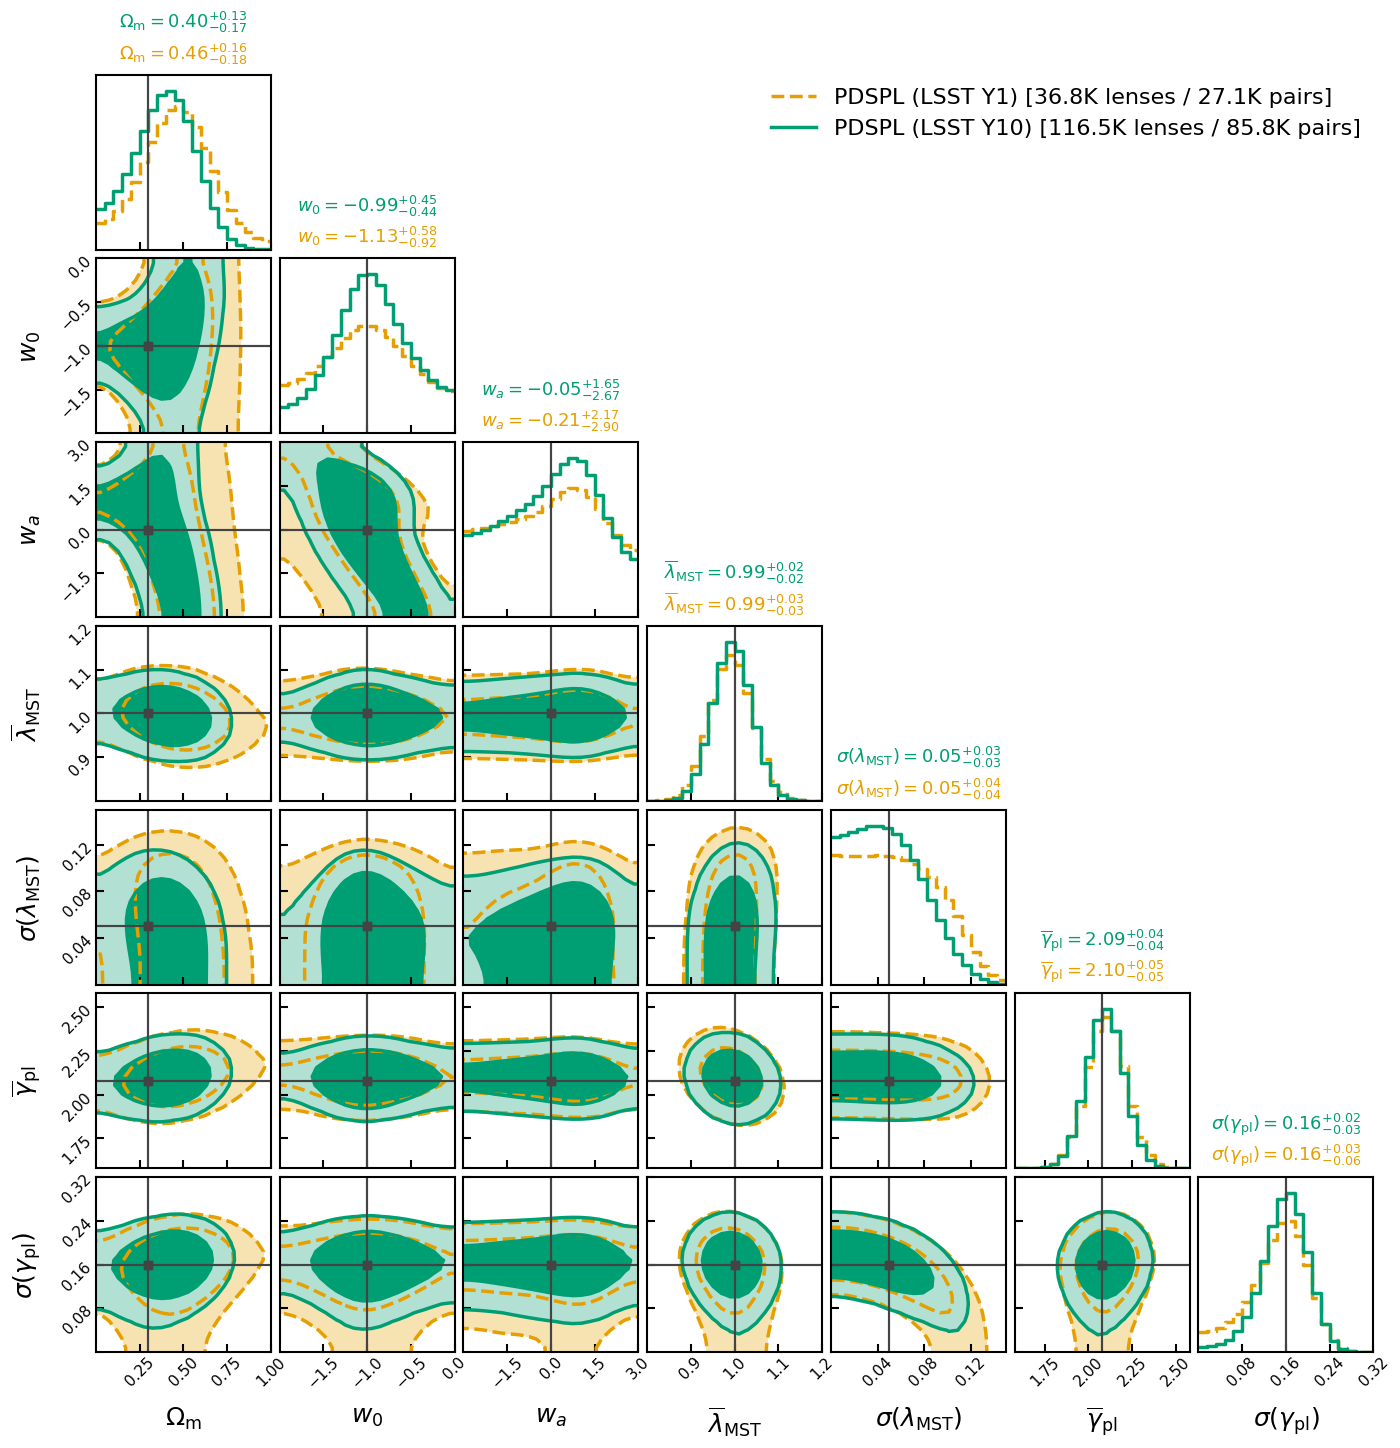

In [10]:
# ── Cell 8: Figure 6 — LSST Y1 vs Y10 ───────────────────────────────────────
print("Generating Figure 6: LSST Y1 vs Y10 forecast...")
fig6 = plot_dspl_corner(
    fixed_scenarios_with_stats, truth, fixed_params,
    scenarios_to_plot=["lsst_y1", "lsst_y10"],
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(14, 14),
    show_multiple_titles=True,
    custom_colors_dict=accessible_colors,
    custom_linestyles_dict={"lsst_y1": "--", "lsst_y10": "-"},
    save_path=f"{FIGURE_DIRECTORY}/pdspls_lsst_y1_y10_forecast_w0waCDM_fixed_scatter.pdf",
)
# plt.close(fig6)
print("  → saved")

Generating Figure 7: LSST Y10 vs 4MOST forecast...
  → saved


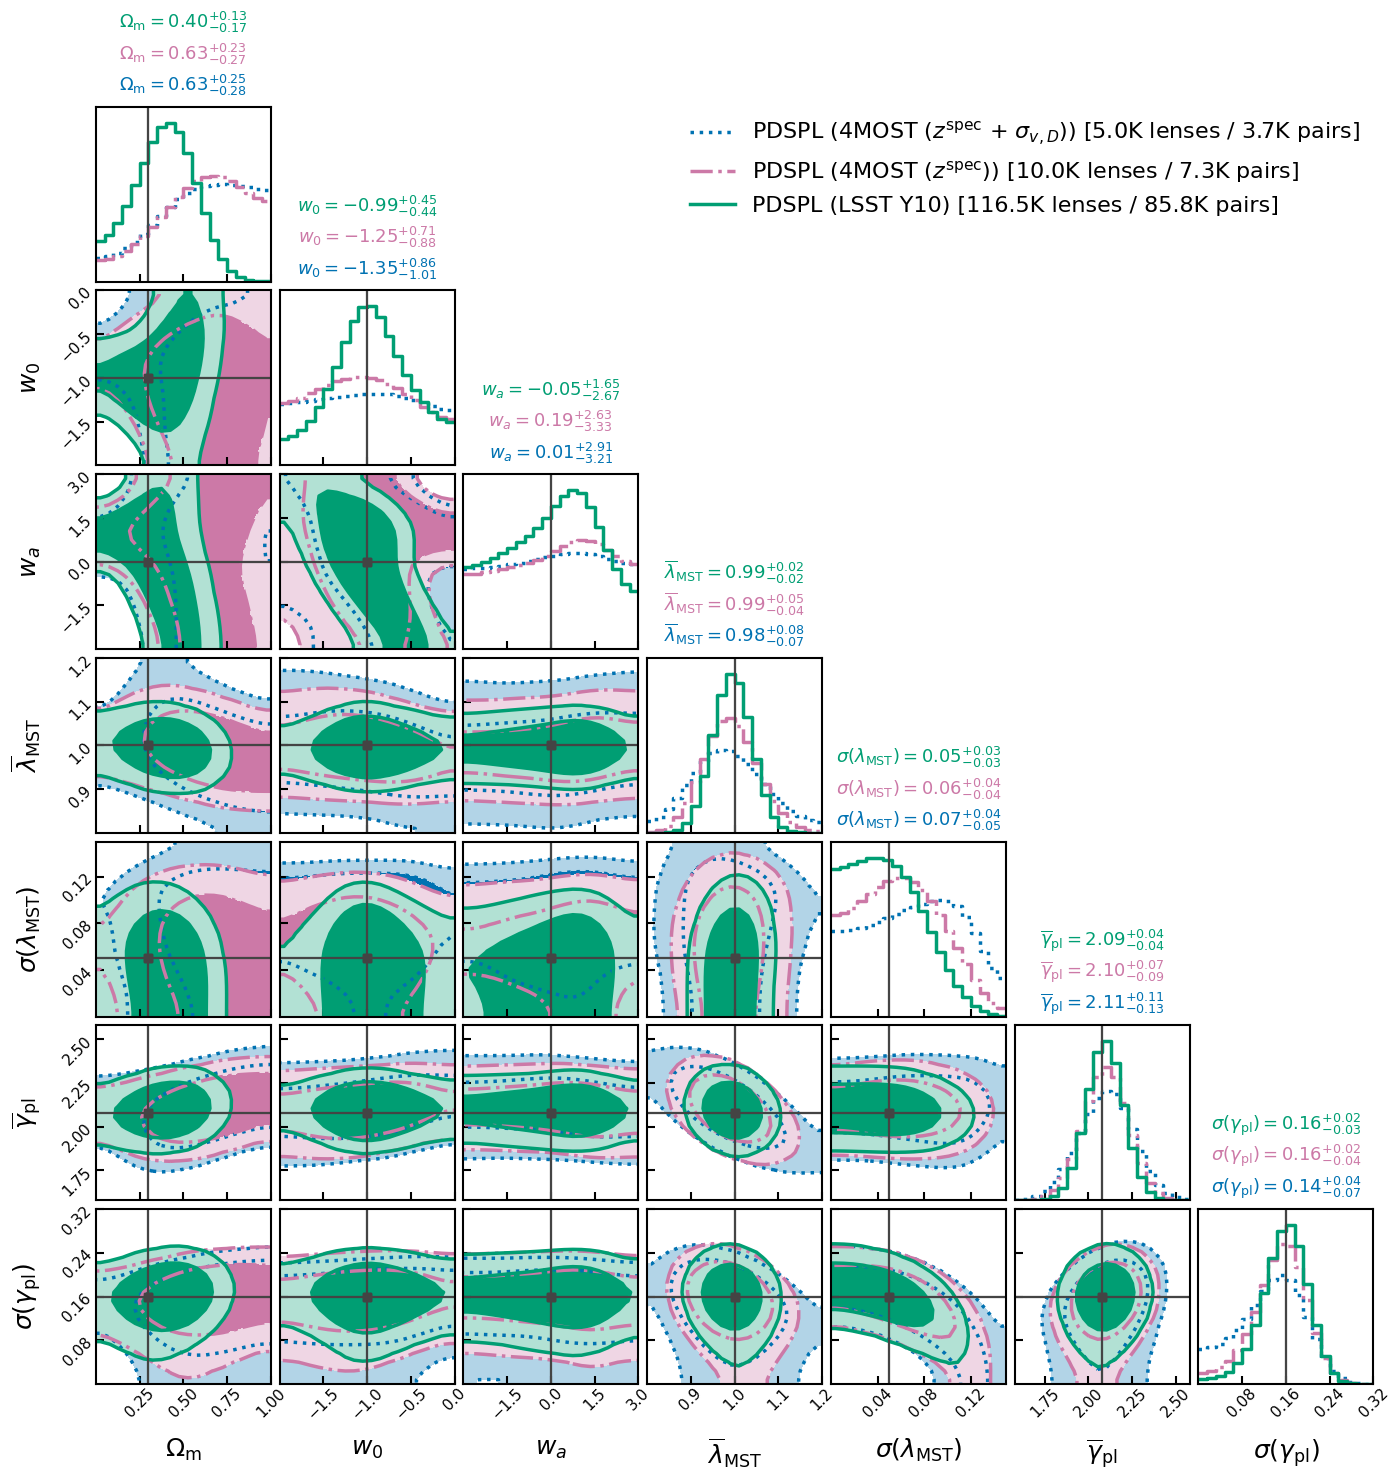

In [11]:
# ── Cell 9: Figure 7 — LSST Y10 vs 4MOST ────────────────────────────────────
print("Generating Figure 7: LSST Y10 vs 4MOST forecast...")
fig7 = plot_dspl_corner(
    fixed_scenarios_with_stats, truth, fixed_params,
    scenarios_to_plot=["lsst_4most_spec-z_sigma_v", "lsst_4most_spec-z", "lsst_y10"],
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(14, 14),
    show_multiple_titles=True,
    custom_colors_dict=accessible_colors,
    custom_linestyles_dict={
        "lsst_4most_spec-z_sigma_v": ":",
        "lsst_4most_spec-z":         "-.",
        "lsst_y10":                  "-",
    },
    save_path=f"{FIGURE_DIRECTORY}/pdspls_lsst_y10_vs_4MOST_forecast_w0waCDM_fixed_scatter.pdf",
)
# plt.close(fig7)
print("  → saved")

Generating Figure 8: DSPL vs PDSPL Y10 forecast...
  → saved


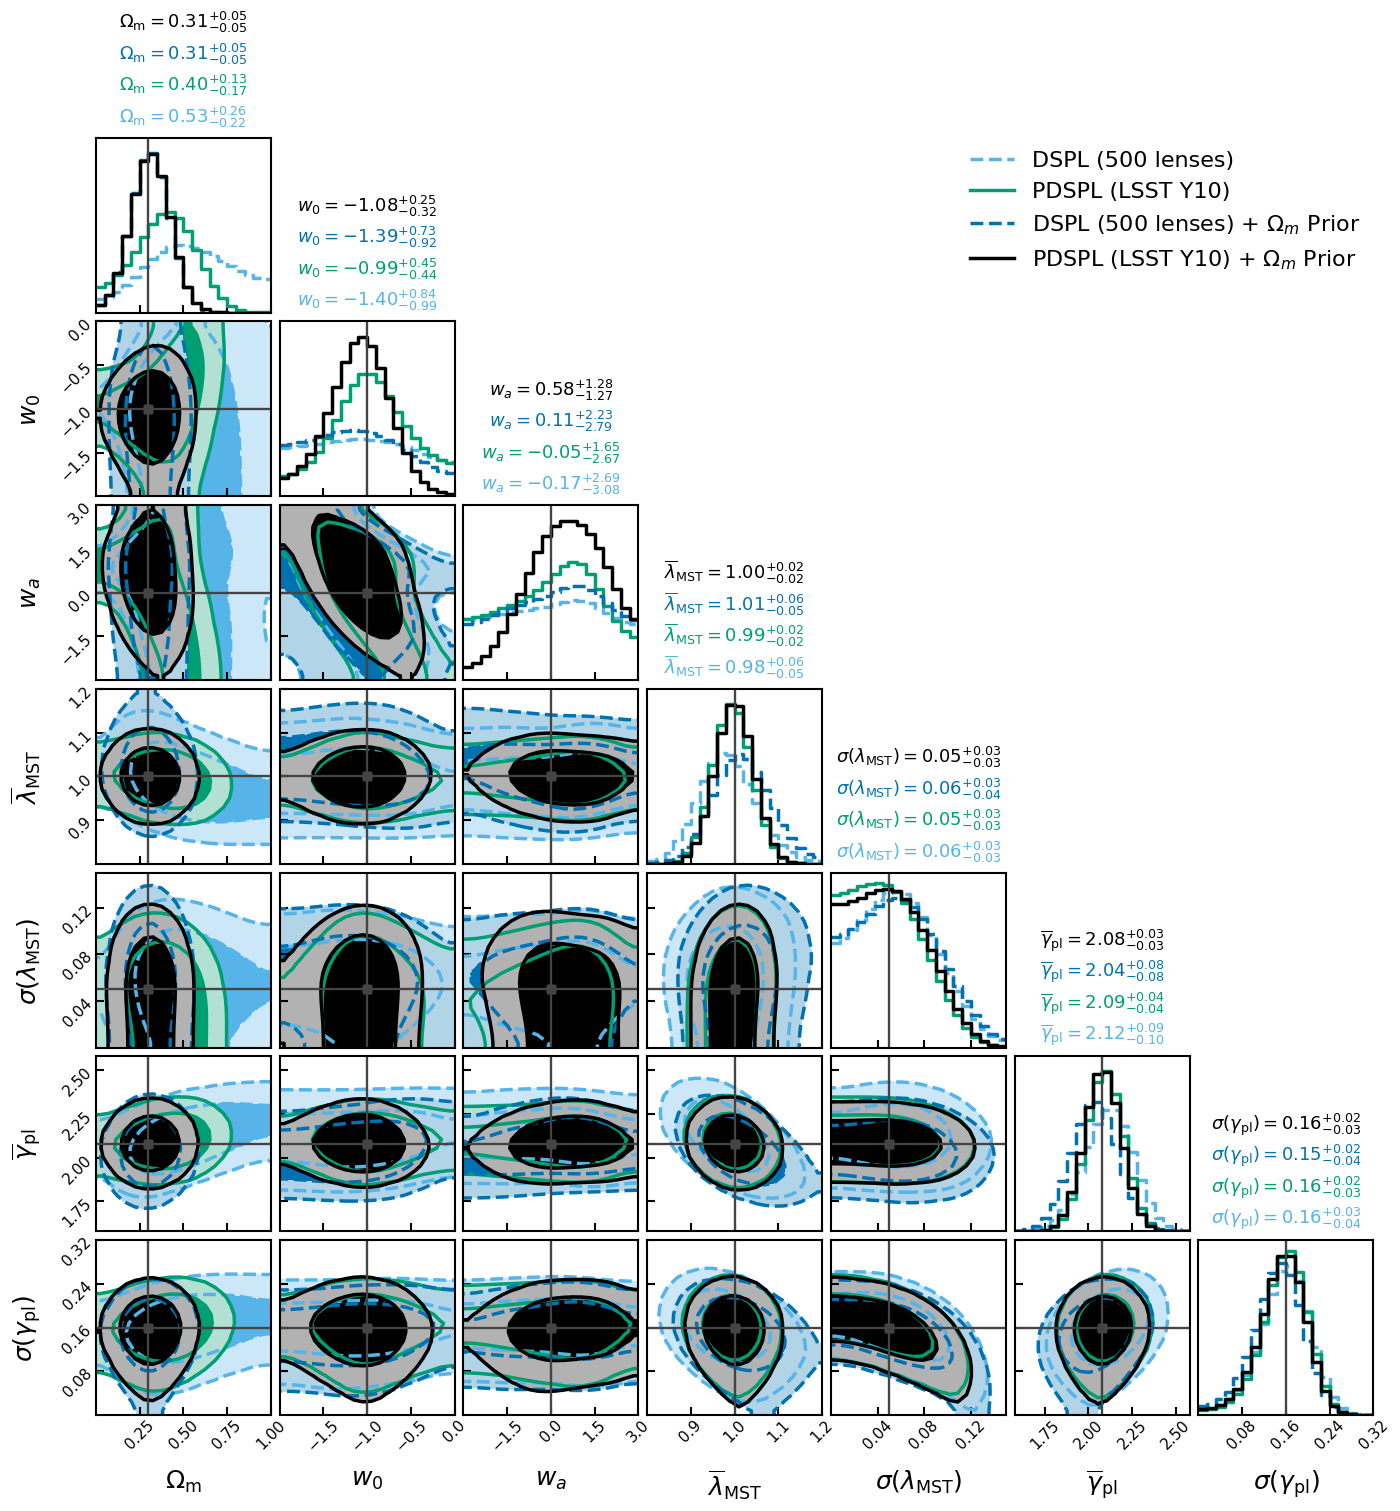

In [12]:
# ── Cell 10: Figure 8 — DSPL vs PDSPL (LSST Y10) with/without Ωm prior ──────
print("Generating Figure 8: DSPL vs PDSPL Y10 forecast...")
fig8 = plot_dspl_corner(
    fixed_scenarios, truth, fixed_params,
    scenarios_to_plot=["DSPL", "lsst_y10", "DSPL_om_prior", "lsst_y10_om_prior"],
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(14, 14),
    show_multiple_titles=True,
    custom_colors_dict=accessible_colors,
    custom_linestyles_dict={
        "DSPL":               "--",
        "lsst_y10":           "-",
        "DSPL_om_prior":      "--",
        "lsst_y10_om_prior":  "-",
    },
    save_path=f"{FIGURE_DIRECTORY}/pdspl_vs_dspl_forecast_w0waCDM_fixed_scatter.pdf",
)
# plt.close(fig8)
print("  → saved")

Generating Figure 9: beta_E vs D (photo-z vs spec-z)...
  → saved


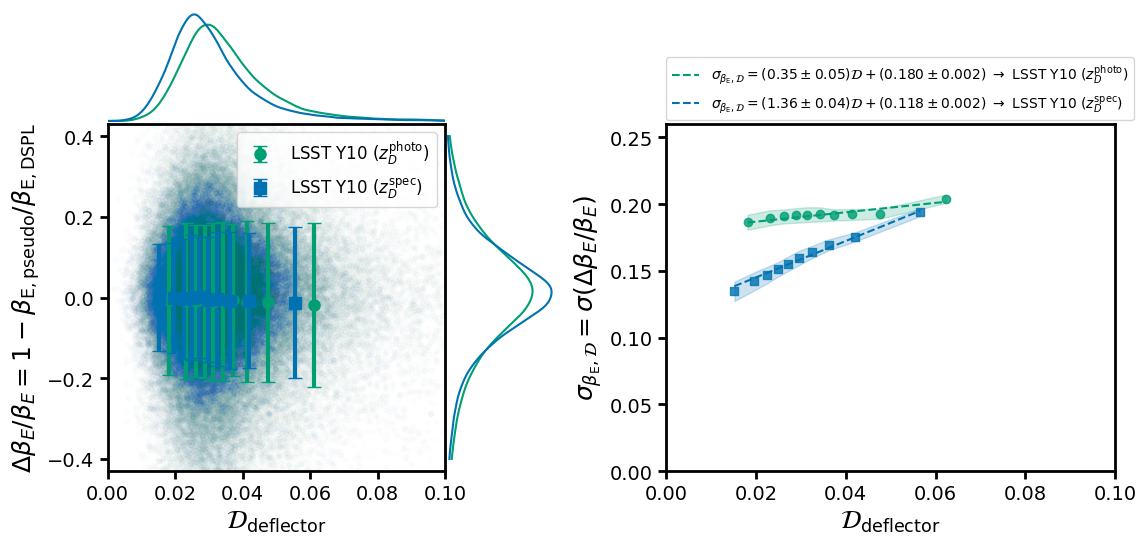

In [13]:
# ── Cell 11: Figure 9 — β_E vs D (photo-z vs spec-z, Appendix B) ─────────────
#
# Important: pass pdspl_samples_expt (with keys lsst_y10_photo_z / lsst_y10_spec_z)
# and the corresponding mc_results_expt — NOT the main pdspl_samples dict.
print("Generating Figure 9: beta_E vs D (photo-z vs spec-z)...")
fig9 = plot_beta_E_vs_D_MC(
    pdspl_samples_expt, mc_results_expt,
    fit_type="linear",
    custom_colors_dict=accessible_colors,
    custom_markers_dict=accessible_markers,
    save_path=f"{FIGURE_DIRECTORY}/beta_E_vs_D_LSST_Y10_photo_vs_spec-z.png",
    legend_fontsize=10
)
# plt.close(fig9)
print("  → saved")

In [14]:
# ── Cell 12: Figure 10 — Photo-z vs spec-z cosmological forecast ──────────────
print("Generating Figure 10: photo-z vs spec-z cosmological forecast...")
fig10 = plot_dspl_corner(
    photo_specz_scenarios, truth, fixed_params,
    scenarios_to_plot=["lsst_y10_baseline", "lsst_y10_zD_spec", "lsst_y10_all_spec"],
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(14, 14),
    show_multiple_titles=True,
    custom_colors_dict=accessible_colors,
    custom_linestyles_dict={
        "lsst_y10_baseline": "-",
        "lsst_y10_zD_spec":  "--",
        "lsst_y10_all_spec": "-.",
    },
    save_path=f"{FIGURE_DIRECTORY}/lsst_y10_photoz_vs_specz_forecast.pdf",
)
plt.close(fig10)
print("  → saved")

Generating Figure 10: photo-z vs spec-z cosmological forecast...


  → saved


Generating Figures 11 & 12: free scatter forecasts...
  → Figure 11 saved
  → Figure 12 saved

✓ All figures saved to: ../figures/all_paper_figures


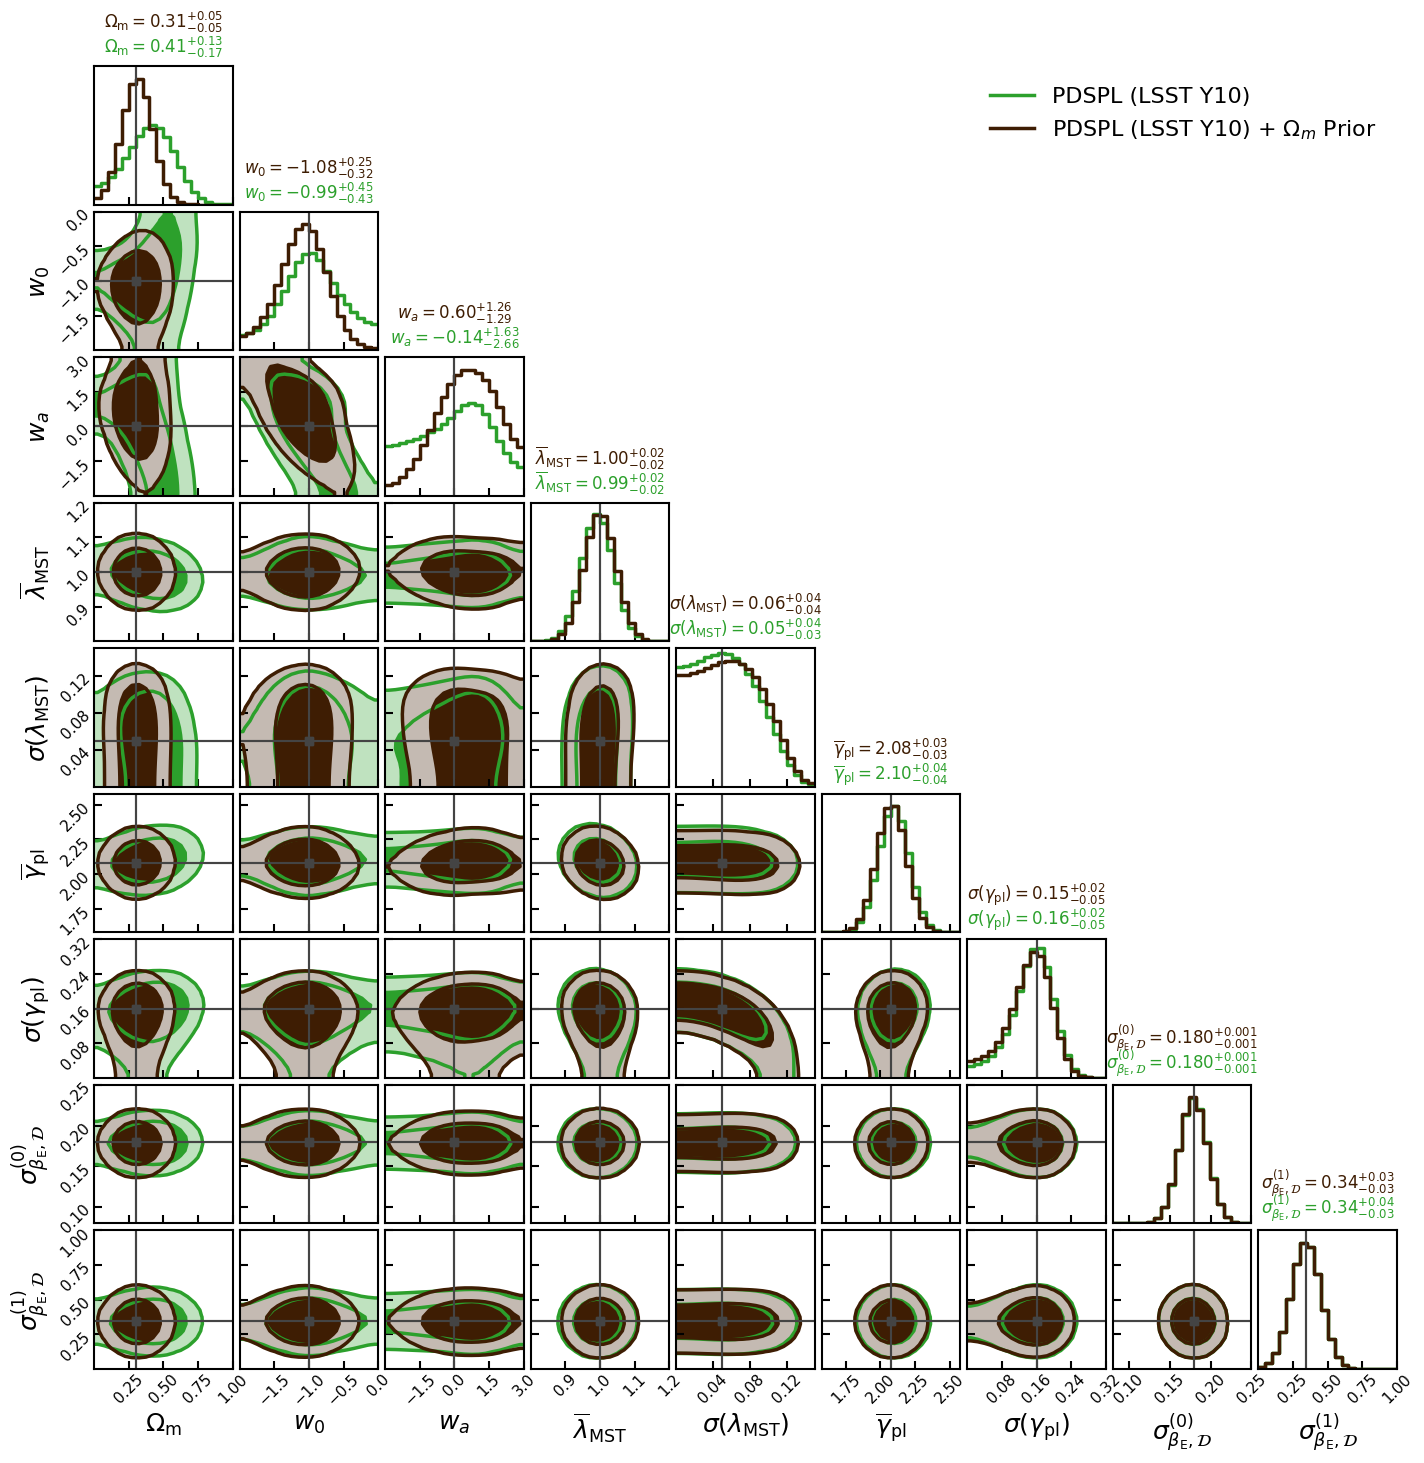

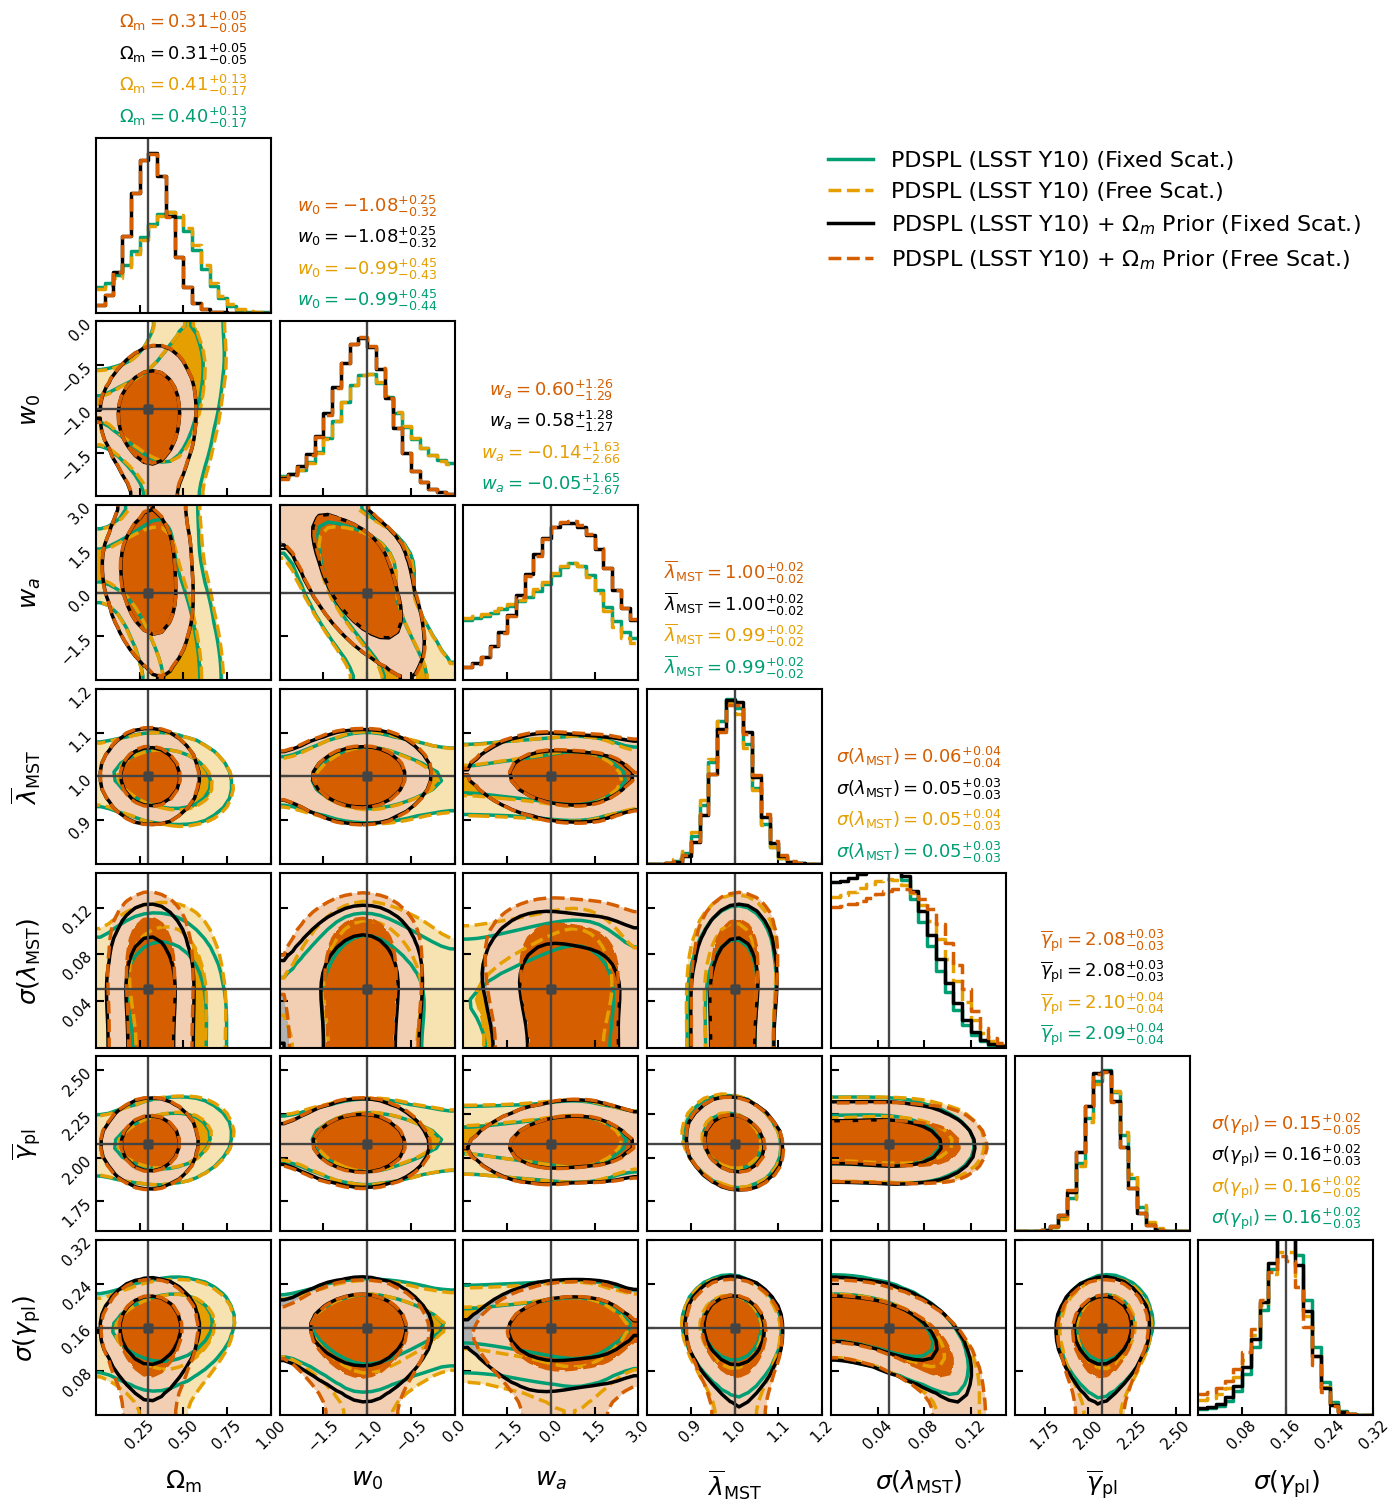

In [15]:
# ── Cell 13: Figures 11 & 12 — Free vs fixed scatter ─────────────────────────
print("Generating Figures 11 & 12: free scatter forecasts...")

# Retrieve calibrated quadrature fit coefficients to set truth lines
coeffs_y10 = pdspl_samples["lsst_y10"]["pairs_analysis"]["scatter_vs_dissimilarity_fit_coeffs"]
custom_truth_free = truth.copy()
custom_truth_free["beta_c0"] = coeffs_y10[1]   # c0_floor
custom_truth_free["beta_c1"] = coeffs_y10[0]   # c1_slope

custom_ranges_free = custom_ranges + [(0.08, 0.25), (0, 1.0)]  # beta_c0, beta_c1

# Figure 11: free scatter posteriors (w/ and w/o Ωm prior)
fig11 = plot_dspl_corner(
    free_scenarios, custom_truth_free, fixed_params,
    scenarios_to_plot=["lsst_y10", "lsst_y10_om_prior"],
    custom_ranges=custom_ranges_free,
    latex_labels=latex_labels, figsize=(14, 14),
    show_multiple_titles=True,
    save_path=f"{FIGURE_DIRECTORY}/free_scatter_lsst_y10_forecast_w0waCDM.pdf",
    titles_fontsize=12,
)
# plt.close(fig11)
print("  → Figure 11 saved")

# Figure 12: fixed vs free scatter comparison
merged = {}
for k in ["lsst_y10", "lsst_y10_om_prior"]:
    merged[f"fixed_{k}"] = {
        "name":    fixed_scenarios[k]["name"] + " (Fixed Scat.)",
        "samples": fixed_scenarios[k]["samples"][:, :7],
        "color":   C_GREEN if "om" not in k else C_BLACK,
    }
    merged[f"free_{k}"] = {
        "name":    free_scenarios[k]["name"] + " (Free Scat.)",
        "samples": free_scenarios[k]["samples"][:, :7],
        "color":   C_ORANGE if "om" not in k else C_VERMILION,
    }

fig12 = plot_dspl_corner(
    merged, truth, fixed_params,
    scenarios_to_plot=[
        "fixed_lsst_y10", "free_lsst_y10",
        "fixed_lsst_y10_om_prior", "free_lsst_y10_om_prior",
    ],
    custom_ranges=custom_ranges, latex_labels=latex_labels, figsize=(14, 14),
    show_multiple_titles=True,
    custom_linestyles_dict={
        "fixed_lsst_y10":           "-",
        "free_lsst_y10":            "--",
        "fixed_lsst_y10_om_prior":  "-",
        "free_lsst_y10_om_prior":   "--",
    },
    save_path=f"{FIGURE_DIRECTORY}/free_vs_fixed_scatter_lsst_y10_forecast_w0waCDM.pdf",
)
# plt.close(fig12)
print("  → Figure 12 saved")

print(f"\n✓ All figures saved to: {FIGURE_DIRECTORY}")

In [16]:
# ── Cell 14: Generate LaTeX Summary Table for Cosmological Forecasts ─────────
def format_latex_constraint(samples, decimals=2):
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])
    lower_err = q50 - q16
    upper_err = q84 - q50
    
    # # If the errors are symmetric within 10%, use \pm
    # if abs(upper_err - lower_err) / max(upper_err, lower_err) < 0.1:
    #     avg_err = (upper_err + lower_err) / 2.0
    #     return f"${q50:.{decimals}f} \\pm {avg_err:.{decimals}f}$"
    # else:
    return f"${q50:.{decimals}f}^{{+{upper_err:.{decimals}f}}}_{{-{lower_err:.{decimals}f}}}$"

sampled_params = ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
decimal_places = [2, 2, 2, 3, 3, 3, 3]

latex_row_names = {
    'DSPL': 'DSPL (500 lenses)',
    'lsst_y1': 'PDSPL (LSST Y1)',
    'lsst_y10': 'PDSPL (LSST Y10)',
    'lsst_4most_spec-z': 'PDSPL (4MOST $z^{\\rm spec}$)',
    'lsst_4most_spec-z_sigma_v': 'PDSPL (4MOST $z^{\\rm spec}$ + $\\sigma_v$)',
}

print("\\begin{sidewaystable}[ht]")
print("\\centering")
print("\\begin{threeparttable}")
print("\\caption{Cosmological forecast constraints for the PDSPL samples and 500 DSPLs.}\\label{tab:forecast_results}")
print("\\vspace{1em}")
print("\\begin{tabular}{l" + "c" * len(sampled_params) + "}")
print("\\toprule")
print("Sample & $\\Omega_{\\rm m}$ & $w_0$ & $w_a$ & $\\overline\\lambda_{\\rm MST}$ & $\\sigma(\\lambda_{\\rm MST})$ & $\\overline\\gamma_{\\rm pl}$ & $\\sigma(\\gamma_{\\rm pl})$ \\\\")
print("\\midrule")

# Truth values
truth_vals = [0.3, -1.0, 0.0, 1.0, 0.05, 2.078, 0.16]
truth_strs = [f"{val:.{dp}f}" for val, dp in zip(truth_vals, decimal_places)]
print("TRUTH & " + " & ".join(truth_strs) + " \\\\")
print("\\midrule")

# 1. Uniform Prior Block
print("\\multicolumn{8}{l}{\\textbf{Flat $w_0w_a$CDM}} \\\\")
print("\\midrule")
for key, row_name in latex_row_names.items():
    if key in fixed_scenarios and 'samples' in fixed_scenarios[key]:
        samples = fixed_scenarios[key]['samples']
        cols = [row_name]
        for p_idx, _ in enumerate(sampled_params):
            cols.append(format_latex_constraint(samples[:, p_idx], decimals=decimal_places[p_idx]))
        print(" & ".join(cols) + " \\\\")

print("\\midrule")

# 2. Omega_m Prior Block
print("\\multicolumn{8}{l}{\\textbf{Flat $w_0w_a$CDM + $\\Omega_{m}$ prior$^\\dagger$}} \\\\")
print("\\midrule")
for key, row_name in latex_row_names.items():
    key_prior = key + '_om_prior'
    if key_prior in fixed_scenarios and 'samples' in fixed_scenarios[key_prior]:
        samples = fixed_scenarios[key_prior]['samples']
        cols = [row_name]
        for p_idx, _ in enumerate(sampled_params):
            cols.append(format_latex_constraint(samples[:, p_idx], decimals=decimal_places[p_idx]))
        print(" & ".join(cols) + " \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\begin{tablenotes}")
print("\\item[$\\dagger$] The prior on $\\Omega_{\\rm m}$ is $\\mathcal{N}(0.3, 0.05)$.")
print("\\end{tablenotes}")
print("\\end{threeparttable}")
print("\\end{sidewaystable}")

\begin{sidewaystable}[ht]
\centering
\begin{threeparttable}
\caption{Cosmological forecast constraints for the PDSPL samples and 500 DSPLs.}\label{tab:forecast_results}
\vspace{1em}
\begin{tabular}{lccccccc}
\toprule
Sample & $\Omega_{\rm m}$ & $w_0$ & $w_a$ & $\overline\lambda_{\rm MST}$ & $\sigma(\lambda_{\rm MST})$ & $\overline\gamma_{\rm pl}$ & $\sigma(\gamma_{\rm pl})$ \\
\midrule
TRUTH & 0.30 & -1.00 & 0.00 & 1.000 & 0.050 & 2.078 & 0.160 \\
\midrule
\multicolumn{8}{l}{\textbf{Flat $w_0w_a$CDM}} \\
\midrule
DSPL (500 lenses) & $0.53^{+0.26}_{-0.22}$ & $-1.40^{+0.84}_{-0.99}$ & $-0.17^{+2.69}_{-3.08}$ & $0.981^{+0.056}_{-0.046}$ & $0.056^{+0.033}_{-0.033}$ & $2.123^{+0.088}_{-0.104}$ & $0.163^{+0.025}_{-0.036}$ \\
PDSPL (LSST Y1) & $0.46^{+0.16}_{-0.18}$ & $-1.13^{+0.58}_{-0.92}$ & $-0.21^{+2.17}_{-2.90}$ & $0.992^{+0.028}_{-0.026}$ & $0.054^{+0.040}_{-0.037}$ & $2.104^{+0.049}_{-0.051}$ & $0.157^{+0.026}_{-0.058}$ \\


PDSPL (LSST Y10) & $0.40^{+0.13}_{-0.17}$ & $-0.99^{+0.45}_{-0.44}$ & $-0.05^{+1.65}_{-2.67}$ & $0.994^{+0.019}_{-0.019}$ & $0.045^{+0.031}_{-0.030}$ & $2.094^{+0.035}_{-0.035}$ & $0.164^{+0.017}_{-0.032}$ \\
PDSPL (4MOST $z^{\rm spec}$) & $0.63^{+0.23}_{-0.27}$ & $-1.25^{+0.71}_{-0.88}$ & $0.19^{+2.63}_{-3.33}$ & $0.988^{+0.051}_{-0.044}$ & $0.059^{+0.035}_{-0.036}$ & $2.103^{+0.073}_{-0.085}$ & $0.156^{+0.025}_{-0.043}$ \\
PDSPL (4MOST $z^{\rm spec}$ + $\sigma_v$) & $0.63^{+0.25}_{-0.28}$ & $-1.35^{+0.86}_{-1.01}$ & $0.01^{+2.91}_{-3.21}$ & $0.983^{+0.082}_{-0.070}$ & $0.074^{+0.040}_{-0.048}$ & $2.108^{+0.110}_{-0.127}$ & $0.142^{+0.040}_{-0.070}$ \\
\midrule
\multicolumn{8}{l}{\textbf{Flat $w_0w_a$CDM + $\Omega_{m}$ prior$^\dagger$}} \\
\midrule
DSPL (500 lenses) & $0.31^{+0.05}_{-0.05}$ & $-1.39^{+0.73}_{-0.92}$ & $0.11^{+2.23}_{-2.79}$ & $1.013^{+0.056}_{-0.048}$ & $0.056^{+0.035}_{-0.035}$ & $2.036^{+0.083}_{-0.084}$ & $0.150^{+0.024}_{-0.036}$ \\
PDSPL (LSST Y1) & $0.31^{+0.05}